**Barangay-Level Flood Risk Classification and Mapping in the City of Manila Using Machine Learning and a Multi-Criteria Disaster Prioritization Index**

Machine Learning - Process

**Objectives:**
- computes the **Composite Susceptibility Index** (CSI)
- computes the **Disaster Prioritization Index** (DPI)
- generates Low/Medium/High risk labels
- trains three machine learning models: Random Forest, Gradient Boosting, and Multi-Layer Perceptron.

The workflow uses the validated 5-year and 25-year flood indicators only. The 100-year return-period layer is excluded from the primary DPI and ML process due to return-period consistency issues.

**Required Files**

- manila_ml_ready_dataset

### Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### Load the ML-Ready Dataset

This step loads the cleaned ML-ready dataset. The dataset should contain only validated 5-year and 25-year flood indicators, population/exposure indicators, vulnerability indicators, and district context features.

The 100-year flood layer is not used for CSI, DPI, or machine learning.

In [9]:
input_path = "/content/manila_ml_ready_dataset.csv"

df = pd.read_csv(input_path)

# Clean column names
df.columns = df.columns.astype(str).str.strip()

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully.
Shape: (897, 19)

Columns:
['Barangay', 'Barangay No', 'psgc_10d', 'city_name', 'brgy_code', 'Flood PCT 5yr', 'Flood PCT 25yr', 'Flood Escalation 5to25', 'Flood Severity Increase 5to25 Sqm', 'Affected Population 5yr', 'Affected Population 25yr', 'Affected Population Increase 5to25', 'Population Density per Hectare', 'District Avg Flood PCT 5yr', 'District Avg Flood PCT 25yr', 'District Avg Population Density per Hectare', 'Relative Flood Risk 25yr vs District', 'Relative Pop Density vs District', 'Area Difference Pct']


,Barangay,Barangay No,psgc_10d,city_name,brgy_code,Flood PCT 5yr,Flood PCT 25yr,Flood Escalation 5to25,Flood Severity Increase 5to25 Sqm,Affected Population 5yr,Affected Population 25yr,Affected Population Increase 5to25,Population Density per Hectare,District Avg Flood PCT 5yr,District Avg Flood PCT 25yr,District Avg Population Density per Hectare,Relative Flood Risk 25yr vs District,Relative Pop Density vs District,Area Difference Pct
0,Barangay 1,1,1.380601e+09,City of Manila - Tondo I / II,133901001,16.680654,42.523980,25.843326,12804.719516,520,1326,806,629.497068,53.293173,74.009798,850.366607,-31.485818,-220.869539,0.038666
1,Barangay 2,2,1.380601e+09,City of Manila - Tondo I / II,133901002,13.399811,43.580300,30.180490,11434.170930,223,726,503,439.740638,53.293173,74.009798,850.366607,-30.429498,-410.625969,0.038627
2,Barangay 3,3,1.380601e+09,City of Manila - Tondo I / II,133901003,71.807098,96.840606,25.033508,9748.188697,885,1193,308,316.379617,53.293173,74.009798,850.366607,22.830808,-533.986990,0.038514
3,Barangay 4,4,1.380601e+09,City of Manila - Tondo I / II,133901004,22.463010,66.297381,43.834370,17618.649730,386,1138,752,427.181509,53.293173,74.009798,850.366607,-7.712417,-423.185098,0.038621
4,Barangay 5,5,1.380601e+09,City of Manila - Tondo I / II,133901005,28.123859,71.659485,43.535626,10771.518285,372,947,575,533.913235,53.293173,74.009798,850.366607,-2.350313,-316.453372,0.038685


### Basic Dataset Validation

This step checks the dataset structure, missing values, duplicate barangay records, and available columns before computing CSI and DPI.


In [10]:
print("Dataset shape:", df.shape)

if "Barangay" in df.columns:
    print("Unique barangays:", df["Barangay"].nunique())
    print("Duplicate barangays:", df["Barangay"].duplicated().sum())

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False))

print("\nData types:")
display(df.dtypes)

Dataset shape: (897, 19)
Unique barangays: 897
Duplicate barangays: 0

Missing values per column:


,0
Barangay,0
Barangay No,0
psgc_10d,0
city_name,0
brgy_code,0
Flood PCT 5yr,0
Flood PCT 25yr,0
Flood Escalation 5to25,0
Flood Severity Increase 5to25 Sqm,0
Affected Population 5yr,0



Data types:


,0
Barangay,object
Barangay No,int64
psgc_10d,float64
city_name,object
brgy_code,int64
Flood PCT 5yr,float64
Flood PCT 25yr,float64
Flood Escalation 5to25,float64
Flood Severity Increase 5to25 Sqm,float64
Affected Population 5yr,int64


### Helper Functions

These functions are used throughout the notebook for:
- numeric conversion,
- min-max normalization,
- reverse normalization for future elevation,
- entropy weight computation,
- safe column checking.


In [11]:
def safe_numeric(df, cols):
    """
    Converts selected columns to numeric if they exist.
    Also removes commas and percent signs if present.
    """
    for col in cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def minmax_positive(series):
    """
    Min-max normalization for positive indicators.
    Higher raw value = higher risk.
    """
    series = pd.to_numeric(series, errors="coerce")
    min_val = series.min()
    max_val = series.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(0.0, index=series.index)

    return (series - min_val) / (max_val - min_val)


def minmax_negative(series):
    """
    Reverse min-max normalization for negative indicators.
    Lower raw value = higher risk.

    Example:
    Lower elevation = higher flood susceptibility.
    """
    series = pd.to_numeric(series, errors="coerce")
    min_val = series.min()
    max_val = series.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(0.0, index=series.index)

    return (max_val - series) / (max_val - min_val)


def entropy_weights(dataframe):
    """
    Computes entropy weights for component scores.
    """
    X = dataframe.copy()
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    X = X.clip(lower=0)

    # Normalize again for safety
    for col in X.columns:
        min_val = X[col].min()
        max_val = X[col].max()

        if max_val != min_val:
            X[col] = (X[col] - min_val) / (max_val - min_val)
        else:
            X[col] = 0

    # Convert normalized values to proportions
    col_sums = X.sum(axis=0)
    P = X.div(col_sums.replace(0, np.nan), axis=1).fillna(0)

    m = len(X)
    k = 1 / np.log(m)

    # Entropy
    P_log = P.replace(0, np.nan)
    entropy = -k * (P * np.log(P_log)).sum(axis=0)
    entropy = entropy.fillna(0)

    diversification = 1 - entropy

    if diversification.sum() == 0:
        weights = pd.Series(
            1 / len(diversification),
            index=diversification.index
        )
    else:
        weights = diversification / diversification.sum()

    return weights, entropy, diversification


def keep_existing(cols, df):
    """
    Returns only columns that exist in the dataframe.
    """
    return [col for col in cols if col in df.columns]


print("Helper functions defined successfully.")

Helper functions defined successfully.


### Convert Required Columns to Numeric

This ensures that all flood, population, density, and district context indicators are properly treated as numeric values.


In [12]:
numeric_cols = [
    # Hazard
    "Flood PCT 5yr",
    "Flood PCT 25yr",
    "Flood Escalation 5to25",
    "Flood Severity Increase 5to25 Sqm",

    # Exposure
    "Affected Population 5yr",
    "Affected Population 25yr",
    "Affected Population Increase 5to25",

    # Vulnerability
    "Population Density per Hectare",

    # District context
    "District Avg Flood PCT 5yr",
    "District Avg Flood PCT 25yr",
    "District Avg Population Density per Hectare",
    "Relative Flood Risk 25yr vs District",
    "Relative Pop Density vs District",

    # Area validation
    "Area Difference Pct",

    # Future elevation support
    "Mean Elevation",
    "mean_elevation",
    "Elevation",
    "elevation",
    "Avg Elevation",
    "avg_elevation"
]

numeric_existing = keep_existing(numeric_cols, df)
df = safe_numeric(df, numeric_existing)

print("Converted numeric columns:")
print(numeric_existing)

print("\nNumeric column missing values:")
display(df[numeric_existing].isna().sum())


Converted numeric columns:
['Flood PCT 5yr', 'Flood PCT 25yr', 'Flood Escalation 5to25', 'Flood Severity Increase 5to25 Sqm', 'Affected Population 5yr', 'Affected Population 25yr', 'Affected Population Increase 5to25', 'Population Density per Hectare', 'District Avg Flood PCT 5yr', 'District Avg Flood PCT 25yr', 'District Avg Population Density per Hectare', 'Relative Flood Risk 25yr vs District', 'Relative Pop Density vs District', 'Area Difference Pct']

Numeric column missing values:


,0
Flood PCT 5yr,0
Flood PCT 25yr,0
Flood Escalation 5to25,0
Flood Severity Increase 5to25 Sqm,0
Affected Population 5yr,0
Affected Population 25yr,0
Affected Population Increase 5to25,0
Population Density per Hectare,0
District Avg Flood PCT 5yr,0
District Avg Flood PCT 25yr,0


### Resolve Column Names

This cell makes the notebook flexible. It detects whether the dataset uses 2020-style column names or 2024-style column names.

If 2024 population columns exist, they are prioritized. Otherwise, the notebook falls back to the older column names.


In [13]:
required_cols = [
    "Barangay",
    "Flood PCT 5yr",
    "Flood PCT 25yr",
    "Flood Escalation 5to25",
    "Flood Severity Increase 5to25 Sqm",
    "Affected Population 5yr",
    "Affected Population 25yr",
    "Affected Population Increase 5to25",
    "Population Density per Hectare"
]

missing_required = [col for col in required_cols if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")
else:
    print("All required columns are present.")

# Column aliases for later cells
affected_5yr_col = "Affected Population 5yr"
affected_25yr_col = "Affected Population 25yr"
affected_increase_col = "Affected Population Increase 5to25"
density_col = "Population Density per Hectare"

# Optional district/context columns
district_flood_5yr_col = "District Avg Flood PCT 5yr" if "District Avg Flood PCT 5yr" in df.columns else None
district_flood_25yr_col = "District Avg Flood PCT 25yr" if "District Avg Flood PCT 25yr" in df.columns else None
district_density_col = "District Avg Population Density per Hectare" if "District Avg Population Density per Hectare" in df.columns else None
relative_flood_col = "Relative Flood Risk 25yr vs District" if "Relative Flood Risk 25yr vs District" in df.columns else None
relative_density_col = "Relative Pop Density vs District" if "Relative Pop Density vs District" in df.columns else None

print("\nResolved columns:")
print("Affected 5yr:", affected_5yr_col)
print("Affected 25yr:", affected_25yr_col)
print("Affected Increase:", affected_increase_col)
print("Density:", density_col)
print("District Flood 5yr:", district_flood_5yr_col)
print("District Flood 25yr:", district_flood_25yr_col)
print("District Density:", district_density_col)
print("Relative Flood:", relative_flood_col)
print("Relative Density:", relative_density_col)

All required columns are present.

Resolved columns:
Affected 5yr: Affected Population 5yr
Affected 25yr: Affected Population 25yr
Affected Increase: Affected Population Increase 5to25
Density: Population Density per Hectare
District Flood 5yr: District Avg Flood PCT 5yr
District Flood 25yr: District Avg Flood PCT 25yr
District Density: District Avg Population Density per Hectare
Relative Flood: Relative Flood Risk 25yr vs District
Relative Density: Relative Pop Density vs District


## CSI Computation

The Composite Susceptibility Index (CSI) represents the physical flood hazard component of the DPI. It uses validated 5-year and 25-year flood hazard indicators only.

The 100-year layer is excluded due to return-period progression issues.

CSI formula:

$$
CSI_i = \frac{norm(FloodPCT5_i) + norm(FloodPCT25_i) + norm(Escalation5to25_i)}{3}
$$


In [14]:
# Normalize hazard indicators
df["norm_flood_pct_5yr"] = minmax_positive(df["Flood PCT 5yr"])
df["norm_flood_pct_25yr"] = minmax_positive(df["Flood PCT 25yr"])
df["norm_flood_escalation_5to25"] = minmax_positive(df["Flood Escalation 5to25"])
df["norm_flood_severity_increase_5to25_sqm"] = minmax_positive(df["Flood Severity Increase 5to25 Sqm"])

# CSI / Hazard Score
df["CSI Score"] = df[
    [
        "norm_flood_pct_5yr",
        "norm_flood_pct_25yr",
        "norm_flood_escalation_5to25",
        "norm_flood_severity_increase_5to25_sqm"
    ]
].mean(axis=1)

df["Hazard Score"] = df["CSI Score"]

print("CSI / Hazard Score computed.")

display(df[
    [
        "Barangay",
        "Flood PCT 5yr",
        "Flood PCT 25yr",
        "Flood Escalation 5to25",
        "Flood Severity Increase 5to25 Sqm",
        "CSI Score"
    ]
].head())

CSI / Hazard Score computed.


,Barangay,Flood PCT 5yr,Flood PCT 25yr,Flood Escalation 5to25,Flood Severity Increase 5to25 Sqm,CSI Score
0,Barangay 1,16.680654,42.523980,25.843326,12804.719516,0.250762
1,Barangay 2,13.399811,43.580300,30.180490,11434.170930,0.256200
2,Barangay 3,71.807098,96.840606,25.033508,9748.188697,0.516438
3,Barangay 4,22.463010,66.297381,43.834370,17618.649730,0.388906
4,Barangay 5,28.123859,71.659485,43.535626,10771.518285,0.403388


### Phase 5A — Exposure Score

The Exposure Score represents the number of residents potentially affected by flooding.

It uses:
- affected population under the 5-year flood scenario,
- affected population under the 25-year flood scenario,
- increase in affected population from 5-year to 25-year scenario.


In [15]:
df["norm_affected_pop_5yr"] = minmax_positive(df[affected_5yr_col])
df["norm_affected_pop_25yr"] = minmax_positive(df[affected_25yr_col])
df["norm_affected_pop_increase_5to25"] = minmax_positive(df[affected_increase_col])

df["Exposure Score"] = df[
    [
        "norm_affected_pop_5yr",
        "norm_affected_pop_25yr",
        "norm_affected_pop_increase_5to25"
    ]
].mean(axis=1)

print("Exposure Score computed.")
display(df[["Barangay", affected_5yr_col, affected_25yr_col, affected_increase_col, "Exposure Score"]].head())


Exposure Score computed.


,Barangay,Affected Population 5yr,Affected Population 25yr,Affected Population Increase 5to25,Exposure Score
0,Barangay 1,520,1326,806,0.083259
1,Barangay 2,223,726,503,0.046313
2,Barangay 3,885,1193,308,0.069992
3,Barangay 4,386,1138,752,0.072165
4,Barangay 5,372,947,575,0.059454


### Phase 5B — Optional Elevation Detection

This notebook currently works without elevation data. However, it is designed to include elevation later.

If an elevation column is found, it will be reverse-normalized because lower elevation indicates higher flood susceptibility.


In [16]:
possible_elevation_cols = [
    "Mean Elevation",
    "mean_elevation",
    "Elevation",
    "elevation",
    "Avg Elevation",
    "avg_elevation",
    "mean_elev",
    "elev_mean"
]

elevation_col = None

for col in possible_elevation_cols:
    if col in df.columns:
        elevation_col = col
        break

if elevation_col is not None:
    df["norm_elevation_susceptibility"] = minmax_negative(df[elevation_col])
    print("Elevation column detected and included:", elevation_col)
else:
    print("No elevation column detected. Vulnerability Score will be computed without elevation.")


No elevation column detected. Vulnerability Score will be computed without elevation.


### Phase 5C — Vulnerability Score

Current implementation uses demographic vulnerability indicators because elevation data is not yet available.

Current indicators:
- population density,
- population growth rate,
- density growth, if available.

Future-ready extension:
- If elevation data is added later, elevation susceptibility will automatically be included.


In [18]:
vulnerability_norm_cols = []

# Population density
df["norm_population_density"] = minmax_positive(df[density_col])
vulnerability_norm_cols.append("norm_population_density")

# Relative population density vs district
if relative_density_col is not None:
    df["norm_relative_population_density"] = minmax_positive(df[relative_density_col])
    vulnerability_norm_cols.append("norm_relative_population_density")

# Optional elevation susceptibility
if elevation_col is not None:
    vulnerability_norm_cols.append("norm_elevation_susceptibility")

df["Vulnerability Score"] = df[vulnerability_norm_cols].mean(axis=1)

print("Vulnerability Score computed using:")
print(vulnerability_norm_cols)

display_cols = ["Barangay", density_col]

if relative_density_col is not None:
    display_cols.append(relative_density_col)

if elevation_col is not None:
    display_cols.append(elevation_col)

display_cols.append("Vulnerability Score")

display(df[display_cols].head())


Vulnerability Score computed using:
['norm_population_density', 'norm_relative_population_density']


,Barangay,Population Density per Hectare,Relative Pop Density vs District,Vulnerability Score
0,Barangay 1,629.497068,-220.869539,0.160256
1,Barangay 2,439.740638,-410.625969,0.113167
2,Barangay 3,316.379617,-533.986990,0.082554
3,Barangay 4,427.181509,-423.185098,0.110050
4,Barangay 5,533.913235,-316.453372,0.136536


### Phase 5D — Entropy Weighting

Entropy weighting computes objective weights for the three DPI components:
- Hazard Score,
- Exposure Score,
- Vulnerability Score.

The method gives higher weight to components that show greater variation across barangays.


In [19]:
component_cols = [
    "Hazard Score",
    "Exposure Score",
    "Vulnerability Score"
]

component_df = df[component_cols].copy()

entropy_w, entropy_values, diversification_values = entropy_weights(component_df)

weights_table = pd.DataFrame({
    "Component": entropy_w.index,
    "Entropy Value": entropy_values.values,
    "Diversification Value": diversification_values.values,
    "Entropy Weight": entropy_w.values
})

print("Entropy-derived component weights:")
display(weights_table)

print("Weight sum:", entropy_w.sum())


Entropy-derived component weights:


,Component,Entropy Value,Diversification Value,Entropy Weight
0,Hazard Score,0.987678,0.012322,0.141226
1,Exposure Score,0.952110,0.047890,0.548869
2,Vulnerability Score,0.972960,0.027040,0.309904


Weight sum: 1.0


### Phase 5E — Disaster Prioritization Index

The DPI is computed as the weighted sum of the component scores.

Formula:

$$
DPI_i = w_HH_i + w_EE_i + w_VV_i
$$

where:
- $$H_i$$ is the Hazard Score / CSI,
- $$E_i$$ is the Exposure Score,
- $$V_i$$ is the Vulnerability Score,
- $$w_H, w_E, w_V$$ are entropy-derived weights.


In [20]:
df["DPI Score"] = (
    entropy_w["Hazard Score"] * df["Hazard Score"] +
    entropy_w["Exposure Score"] * df["Exposure Score"] +
    entropy_w["Vulnerability Score"] * df["Vulnerability Score"]
)

df["DPI Score 0to100"] = minmax_positive(df["DPI Score"]) * 100

print("DPI Score computed and normalized to 0–100.")
display(df[["Barangay", "Hazard Score", "Exposure Score", "Vulnerability Score", "DPI Score", "DPI Score 0to100"]].head())


DPI Score computed and normalized to 0–100.


,Barangay,Hazard Score,Exposure Score,Vulnerability Score,DPI Score,DPI Score 0to100
0,Barangay 1,0.250762,0.083259,0.160256,0.130777,15.964704
1,Barangay 2,0.256200,0.046313,0.113167,0.096673,10.814973
2,Barangay 3,0.516438,0.069992,0.082554,0.136935,16.894585
3,Barangay 4,0.388906,0.072165,0.110050,0.128638,15.641777
4,Barangay 5,0.403388,0.059454,0.136536,0.131915,16.136591


### Phase 5F — Generate Risk Labels

The DPI scores are classified into three relative priority classes using tertiles:
- Low,
- Medium,
- High.

These labels become the machine learning target variable.


In [21]:
df["DPI Risk Class"] = pd.qcut(
    df["DPI Score 0to100"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

print("DPI Risk Class generated.")
print("\nClass distribution:")
print(df["DPI Risk Class"].value_counts())

display(df[["Barangay", "DPI Score 0to100", "DPI Risk Class"]].head())


DPI Risk Class generated.

Class distribution:
DPI Risk Class
Low       299
Medium    299
High      299
Name: count, dtype: int64


,Barangay,DPI Score 0to100,DPI Risk Class
0,Barangay 1,15.964704,Low
1,Barangay 2,10.814973,Low
2,Barangay 3,16.894585,Medium
3,Barangay 4,15.641777,Low
4,Barangay 5,16.136591,Low


### Risk Class Distribution

This visualization checks whether the Low, Medium, and High classes are reasonably balanced.


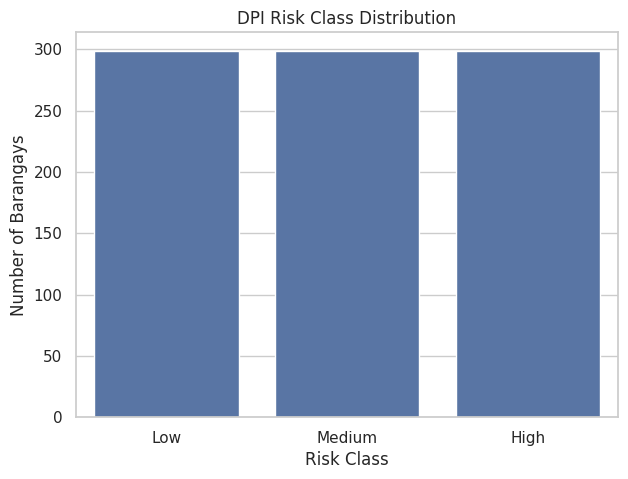

In [22]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="DPI Risk Class", order=["Low", "Medium", "High"])
plt.title("DPI Risk Class Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Number of Barangays")
plt.show()


### Export Dataset With DPI Labels

This exports the dataset containing CSI, component scores, entropy-weighted DPI, and risk labels.

This file can be used for:
- dashboard visualization,
- ML model input preparation,
- thesis documentation.


In [23]:
output_labeled_csv = "/content/manila_ml_ready_with_DPI_labels.csv"
output_labeled_excel = "/content/manila_ml_ready_with_DPI_labels.xlsx"
weights_output_csv = "/content/entropy_component_weights.csv"

df.to_csv(output_labeled_csv, index=False)
df.to_excel(output_labeled_excel, index=False)
weights_table.to_csv(weights_output_csv, index=False)

print("Export complete.")
print("Labeled CSV:", output_labeled_csv)
print("Labeled Excel:", output_labeled_excel)
print("Entropy weights CSV:", weights_output_csv)


Export complete.
Labeled CSV: /content/manila_ml_ready_with_DPI_labels.csv
Labeled Excel: /content/manila_ml_ready_with_DPI_labels.xlsx
Entropy weights CSV: /content/entropy_component_weights.csv


### Phase 6A — Define Features and Target

The ML target is:

`DPI Risk Class`

The features must be raw or engineered indicators only.

Important leakage rule:
Do not include DPI Score, CSI Score, Hazard Score, Exposure Score, Vulnerability Score, or any risk-class-derived values as model inputs.


In [25]:
target_col = "DPI Risk Class"

if target_col not in df.columns:
    raise ValueError(
        f"Target column '{target_col}' not found. "
        "Run DPI computation and risk classification first."
    )

candidate_ml_features = [
    # Hazard indicators
    "Flood PCT 5yr",
    "Flood PCT 25yr",
    "Flood Escalation 5to25",
    "Flood Severity Increase 5to25 Sqm",

    # Exposure indicators
    "Affected Population 5yr",
    "Affected Population 25yr",
    "Affected Population Increase 5to25",

    # Vulnerability indicators
    "Population Density per Hectare",

    # District context indicators
    "District Avg Flood PCT 5yr",
    "District Avg Flood PCT 25yr",
    "District Avg Population Density per Hectare",
    "Relative Flood Risk 25yr vs District",
    "Relative Pop Density vs District",

    # Area validation/context
    "Area Difference Pct"
]

# Optional future elevation raw feature
if elevation_col is not None:
    candidate_ml_features.append(elevation_col)

# Keep only available features
ml_features = [col for col in candidate_ml_features if col in df.columns]

# Remove duplicates
ml_features = list(dict.fromkeys(ml_features))

if len(ml_features) == 0:
    raise ValueError("No ML features found. Check dataset columns.")

print("ML features selected:")
for col in ml_features:
    print("-", col)

print("\nTarget:", target_col)
print("Number of ML features:", len(ml_features))


ML features selected:
- Flood PCT 5yr
- Flood PCT 25yr
- Flood Escalation 5to25
- Flood Severity Increase 5to25 Sqm
- Affected Population 5yr
- Affected Population 25yr
- Affected Population Increase 5to25
- Population Density per Hectare
- District Avg Flood PCT 5yr
- District Avg Flood PCT 25yr
- District Avg Population Density per Hectare
- Relative Flood Risk 25yr vs District
- Relative Pop Density vs District
- Area Difference Pct

Target: DPI Risk Class
Number of ML features: 14


### Create ML Dataset and Check Leakage

This cell builds the final ML table and checks that no DPI-derived columns are accidentally used as features.


In [26]:
leakage_cols = [
    "CSI Score",
    "Hazard Score",
    "Exposure Score",
    "Vulnerability Score",
    "DPI Score",
    "DPI Score 0to100",
    "DPI Risk Class",
    "Primary Hazard Index 5yr25yr",
    "Supplementary Hazard Index 5yr25yr100yr"
]

leakage_in_features = [col for col in ml_features if col in leakage_cols]

if leakage_in_features:
    raise ValueError(f"Data leakage detected in features: {leakage_in_features}")
else:
    print("No leakage columns found in ML features.")

df_model = df[ml_features + [target_col]].copy()

# Drop rows without target
df_model = df_model.dropna(subset=[target_col]).copy()

print("ML dataset shape:", df_model.shape)
display(df_model.head())


No leakage columns found in ML features.
ML dataset shape: (897, 15)


,Flood PCT 5yr,Flood PCT 25yr,Flood Escalation 5to25,Flood Severity Increase 5to25 Sqm,Affected Population 5yr,Affected Population 25yr,Affected Population Increase 5to25,Population Density per Hectare,District Avg Flood PCT 5yr,District Avg Flood PCT 25yr,District Avg Population Density per Hectare,Relative Flood Risk 25yr vs District,Relative Pop Density vs District,Area Difference Pct,DPI Risk Class
0,16.680654,42.523980,25.843326,12804.719516,520,1326,806,629.497068,53.293173,74.009798,850.366607,-31.485818,-220.869539,0.038666,Low
1,13.399811,43.580300,30.180490,11434.170930,223,726,503,439.740638,53.293173,74.009798,850.366607,-30.429498,-410.625969,0.038627,Low
2,71.807098,96.840606,25.033508,9748.188697,885,1193,308,316.379617,53.293173,74.009798,850.366607,22.830808,-533.986990,0.038514,Medium
3,22.463010,66.297381,43.834370,17618.649730,386,1138,752,427.181509,53.293173,74.009798,850.366607,-7.712417,-423.185098,0.038621,Low
4,28.123859,71.659485,43.535626,10771.518285,372,947,575,533.913235,53.293173,74.009798,850.366607,-2.350313,-316.453372,0.038685,Low


### Phase 6B — Train-Test Split and Label Encoding

The dataset is split into training and testing sets using stratification to preserve the Low/Medium/High class distribution.


In [27]:
X = df_model[ml_features]
y = df_model[target_col].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class encoding:")
for class_name, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{class_name} -> {encoded_value}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Class encoding:
High -> 0
Low -> 1
Medium -> 2
Training shape: (717, 14)
Testing shape: (180, 14)


### Phase 6C — Define Machine Learning Models

Three algorithms are trained and compared:
- Random Forest,
- Gradient Boosting,
- Multi-Layer Perceptron.

The tree-based models use median imputation.  
The MLP uses median imputation plus standard scaling.


In [28]:
models = {
    "Random Forest": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "MLP": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            max_iter=1000,
            random_state=42,
            early_stopping=True
        ))
    ])
}

print("Models defined:")
print(list(models.keys()))


Models defined:
['Random Forest', 'Gradient Boosting', 'MLP']


### Phase 7A — Train and Evaluate Models

This step trains each model and evaluates it on the held-out test set using:
- Accuracy,
- Balanced Accuracy,
- F1 Macro,
- F1 Weighted,
- ROC-AUC One-vs-Rest,
- Confusion Matrix,
- Classification Report.

In [29]:
results = []
trained_models = {}
confusion_matrices = {}
classification_reports = {}

for model_name, pipeline in models.items():
    print(f"\n================ {model_name} ================")

    # Train
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    # Predict
    y_pred = pipeline.predict(X_test)

    # Predict probabilities for ROC-AUC
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
        try:
            roc_auc = roc_auc_score(
                y_test,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
        except Exception:
            roc_auc = np.nan
    else:
        roc_auc = np.nan

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc,
        "F1 Macro": f1_macro,
        "F1 Weighted": f1_weighted,
        "ROC-AUC OVR Macro": roc_auc
    })

    # Confusion matrix and report
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[model_name] = cm

    report = classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    classification_reports[model_name] = report

    print("Accuracy:", acc)
    print("Balanced Accuracy:", bal_acc)
    print("F1 Macro:", f1_macro)
    print("F1 Weighted:", f1_weighted)
    print("ROC-AUC OVR Macro:", roc_auc)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

results_df = pd.DataFrame(results).sort_values(by="F1 Macro", ascending=False)
display(results_df)



================ Random Forest ================
Accuracy: 0.9166666666666666
Balanced Accuracy: 0.9166666666666666
F1 Macro: 0.9171903569199485
F1 Weighted: 0.9171903569199487
ROC-AUC OVR Macro: 0.984074074074074

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.92      0.92        60
         Low       0.97      0.93      0.95        60
      Medium       0.86      0.90      0.88        60

    accuracy                           0.92       180
   macro avg       0.92      0.92      0.92       180
weighted avg       0.92      0.92      0.92       180


================ Gradient Boosting ================
Accuracy: 0.9
Balanced Accuracy: 0.9
F1 Macro: 0.9000891265597147
F1 Weighted: 0.9000891265597147
ROC-AUC OVR Macro: 0.9839814814814815

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.93      0.94        60
         Low       0.90      0.92      0.91        60
     

,Model,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,ROC-AUC OVR Macro
0,Random Forest,0.916667,0.916667,0.917190,0.917190,0.984074
2,MLP,0.916667,0.916667,0.916375,0.916375,0.977130
1,Gradient Boosting,0.900000,0.900000,0.900089,0.900089,0.983981


### Confusion Matrices

Confusion matrices show which risk classes are correctly or incorrectly predicted.


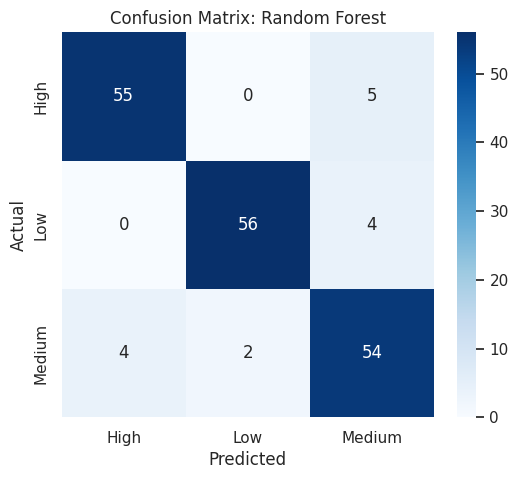

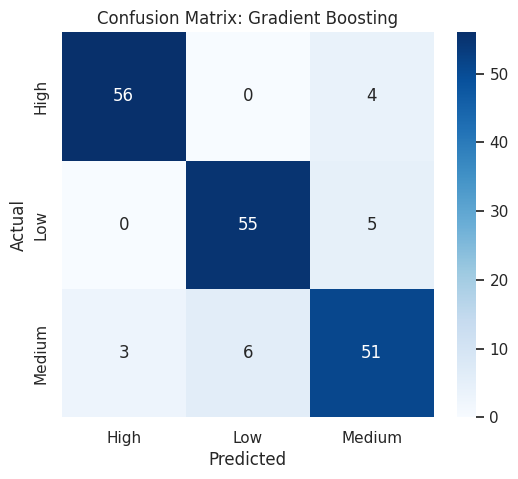

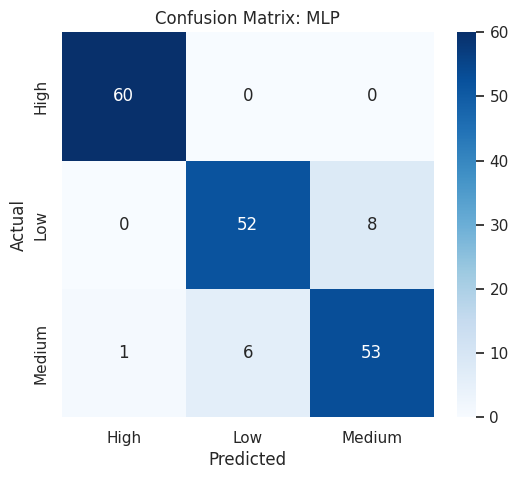

In [30]:
for model_name, cm in confusion_matrices.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


### Phase 7B — Stratified 5-Fold Cross-Validation

Cross-validation provides a more robust estimate of model performance across multiple data splits.


In [31]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "roc_auc_ovr": "roc_auc_ovr"
}

cv_results = []

for model_name, pipeline in models.items():
    print(f"Running cross-validation for {model_name}...")

    scores = cross_validate(
        pipeline,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score=np.nan
    )

    cv_results.append({
        "Model": model_name,
        "CV Accuracy Mean": np.nanmean(scores["test_accuracy"]),
        "CV Accuracy Std": np.nanstd(scores["test_accuracy"]),
        "CV Balanced Accuracy Mean": np.nanmean(scores["test_balanced_accuracy"]),
        "CV Balanced Accuracy Std": np.nanstd(scores["test_balanced_accuracy"]),
        "CV F1 Macro Mean": np.nanmean(scores["test_f1_macro"]),
        "CV F1 Macro Std": np.nanstd(scores["test_f1_macro"]),
        "CV F1 Weighted Mean": np.nanmean(scores["test_f1_weighted"]),
        "CV F1 Weighted Std": np.nanstd(scores["test_f1_weighted"]),
        "CV ROC-AUC OVR Mean": np.nanmean(scores["test_roc_auc_ovr"]),
        "CV ROC-AUC OVR Std": np.nanstd(scores["test_roc_auc_ovr"])
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="CV F1 Macro Mean",
    ascending=False
)

display(cv_results_df)


Running cross-validation for Random Forest...
Running cross-validation for Gradient Boosting...
Running cross-validation for MLP...


,Model,CV Accuracy Mean,CV Accuracy Std,CV Balanced Accuracy Mean,CV Balanced Accuracy Std,CV F1 Macro Mean,CV F1 Macro Std,CV F1 Weighted Mean,CV F1 Weighted Std,CV ROC-AUC OVR Mean,CV ROC-AUC OVR Std
2,MLP,0.928641,0.016370,0.928644,0.016394,0.928540,0.016420,0.928524,0.016344,0.987859,0.004256
0,Random Forest,0.924171,0.017918,0.924218,0.017889,0.924129,0.017603,0.924131,0.017555,0.990382,0.004675
1,Gradient Boosting,0.911893,0.028858,0.911827,0.028856,0.912165,0.028400,0.912244,0.028288,0.986606,0.005875


### Final Model Comparison

This table combines held-out test performance and cross-validation performance.


In [32]:
final_comparison_df = pd.merge(
    results_df,
    cv_results_df,
    on="Model",
    how="left"
)

final_comparison_df = final_comparison_df.sort_values(
    by=["CV F1 Macro Mean", "F1 Macro"],
    ascending=False
)

display(final_comparison_df)


,Model,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,ROC-AUC OVR Macro,CV Accuracy Mean,CV Accuracy Std,CV Balanced Accuracy Mean,CV Balanced Accuracy Std,CV F1 Macro Mean,CV F1 Macro Std,CV F1 Weighted Mean,CV F1 Weighted Std,CV ROC-AUC OVR Mean,CV ROC-AUC OVR Std
1,MLP,0.916667,0.916667,0.916375,0.916375,0.977130,0.928641,0.016370,0.928644,0.016394,0.928540,0.016420,0.928524,0.016344,0.987859,0.004256
0,Random Forest,0.916667,0.916667,0.917190,0.917190,0.984074,0.924171,0.017918,0.924218,0.017889,0.924129,0.017603,0.924131,0.017555,0.990382,0.004675
2,Gradient Boosting,0.900000,0.900000,0.900089,0.900089,0.983981,0.911893,0.028858,0.911827,0.028856,0.912165,0.028400,0.912244,0.028288,0.986606,0.005875


### Phase 7C — Select Best Model

The best model is selected primarily using Cross-Validated F1 Macro, with held-out F1 Macro and Balanced Accuracy as supporting metrics.


In [33]:
best_model_name = final_comparison_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model selected:", best_model_name)

display(final_comparison_df.iloc[[0]])


Best model selected: MLP


,Model,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,ROC-AUC OVR Macro,CV Accuracy Mean,CV Accuracy Std,CV Balanced Accuracy Mean,CV Balanced Accuracy Std,CV F1 Macro Mean,CV F1 Macro Std,CV F1 Weighted Mean,CV F1 Weighted Std,CV ROC-AUC OVR Mean,CV ROC-AUC OVR Std
1,MLP,0.916667,0.916667,0.916375,0.916375,0.97713,0.928641,0.01637,0.928644,0.016394,0.92854,0.01642,0.928524,0.016344,0.987859,0.004256


### Feature Importance

Feature importance is available for Random Forest and Gradient Boosting.  
MLP does not provide native feature importance in the same way.



Feature Importance: Random Forest


,Feature,Importance
5,Affected Population 25yr,0.225695
7,Population Density per Hectare,0.162868
12,Relative Pop Density vs District,0.147755
4,Affected Population 5yr,0.145224
6,Affected Population Increase 5to25,0.063985
1,Flood PCT 25yr,0.056795
11,Relative Flood Risk 25yr vs District,0.043113
0,Flood PCT 5yr,0.037804
2,Flood Escalation 5to25,0.028670
3,Flood Severity Increase 5to25 Sqm,0.028239


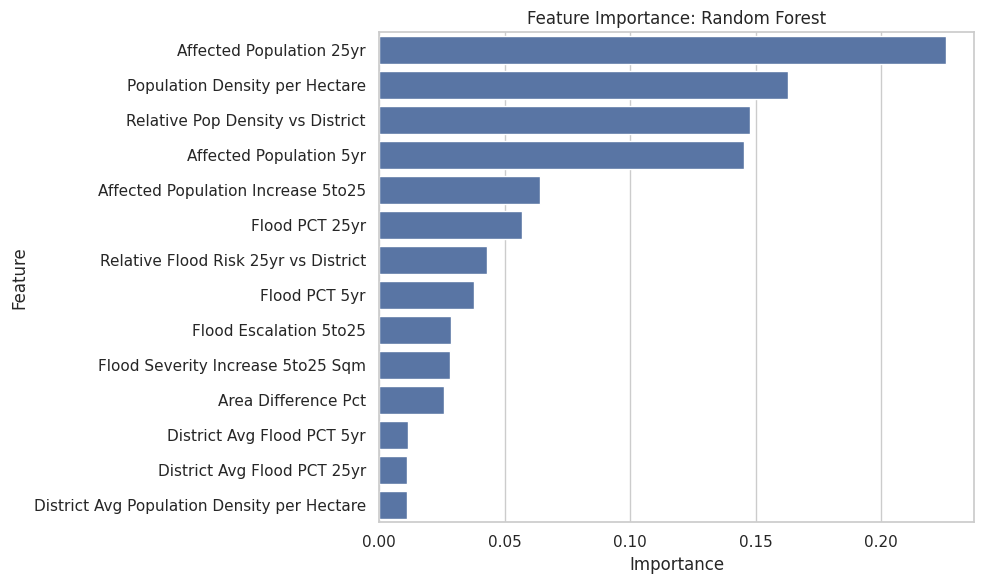


Feature Importance: Gradient Boosting


,Feature,Importance
5,Affected Population 25yr,0.596721
12,Relative Pop Density vs District,0.135981
7,Population Density per Hectare,0.131177
11,Relative Flood Risk 25yr vs District,0.047363
1,Flood PCT 25yr,0.036678
4,Affected Population 5yr,0.022038
6,Affected Population Increase 5to25,0.012594
3,Flood Severity Increase 5to25 Sqm,0.007593
0,Flood PCT 5yr,0.003904
13,Area Difference Pct,0.002913


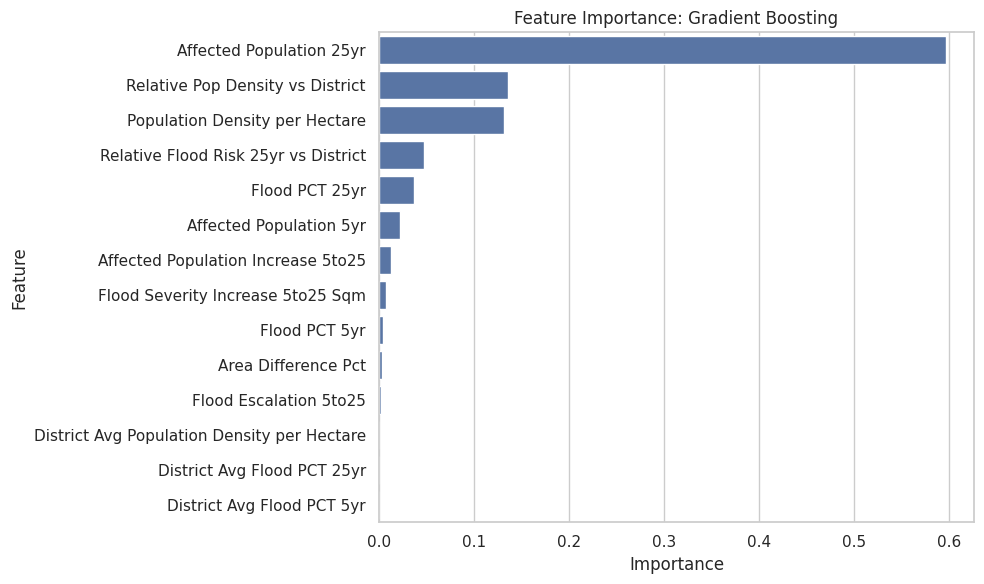

In [34]:
for model_name in ["Random Forest", "Gradient Boosting"]:
    if model_name in trained_models:
        pipeline = trained_models[model_name]
        model = pipeline.named_steps["model"]

        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_

            importance_df = pd.DataFrame({
                "Feature": ml_features,
                "Importance": importances
            }).sort_values(by="Importance", ascending=False)

            print(f"\nFeature Importance: {model_name}")
            display(importance_df)

            plt.figure(figsize=(10, 6))
            sns.barplot(
                data=importance_df,
                x="Importance",
                y="Feature"
            )
            plt.title(f"Feature Importance: {model_name}")
            plt.xlabel("Importance")
            plt.ylabel("Feature")
            plt.tight_layout()
            plt.show()


### Phase 7D — Generate Final Predictions

The best model is applied to all barangays to generate predicted risk classes and prediction confidence values. These will be used in the dashboard.


In [35]:
X_all = df[ml_features].copy()

df["ML Predicted Class Encoded"] = best_model.predict(X_all)
df["ML Predicted Risk Class"] = label_encoder.inverse_transform(df["ML Predicted Class Encoded"])

if hasattr(best_model, "predict_proba"):
    prediction_proba = best_model.predict_proba(X_all)
    df["ML Prediction Confidence"] = prediction_proba.max(axis=1)
else:
    df["ML Prediction Confidence"] = np.nan

df["Best Model"] = best_model_name

display(df[[
    "Barangay",
    "DPI Risk Class",
    "ML Predicted Risk Class",
    "ML Prediction Confidence",
    "Best Model"
]].head())


,Barangay,DPI Risk Class,ML Predicted Risk Class,ML Prediction Confidence,Best Model
0,Barangay 1,Low,Low,0.649846,MLP
1,Barangay 2,Low,Low,0.934919,MLP
2,Barangay 3,Medium,Low,0.573598,MLP
3,Barangay 4,Low,Medium,0.563137,MLP
4,Barangay 5,Low,Medium,0.601373,MLP


### Export Final Outputs

This exports:
- final DPI and ML prediction dataset,
- model comparison table,
- cross-validation results,
- best trained model,
- label encoder.


In [36]:
final_output_csv = "/content/manila_final_DPI_ML_predictions.csv"
final_output_excel = "/content/manila_final_DPI_ML_predictions.xlsx"

model_comparison_csv = "/content/model_comparison_results.csv"
cv_results_csv = "/content/cross_validation_results.csv"

best_model_path = "/content/best_flood_risk_model.pkl"
label_encoder_path = "/content/label_encoder.pkl"

df.to_csv(final_output_csv, index=False)
df.to_excel(final_output_excel, index=False)

final_comparison_df.to_csv(model_comparison_csv, index=False)
cv_results_df.to_csv(cv_results_csv, index=False)

joblib.dump(best_model, best_model_path)
joblib.dump(label_encoder, label_encoder_path)

print("Final outputs exported:")
print("Final DPI + ML CSV:", final_output_csv)
print("Final DPI + ML Excel:", final_output_excel)
print("Model comparison CSV:", model_comparison_csv)
print("CV results CSV:", cv_results_csv)
print("Best model:", best_model_path)
print("Label encoder:", label_encoder_path)


Final outputs exported:
Final DPI + ML CSV: /content/manila_final_DPI_ML_predictions.csv
Final DPI + ML Excel: /content/manila_final_DPI_ML_predictions.xlsx
Model comparison CSV: /content/model_comparison_results.csv
CV results CSV: /content/cross_validation_results.csv
Best model: /content/best_flood_risk_model.pkl
Label encoder: /content/label_encoder.pkl


### Summary Outputs


In [37]:
print("================ ENTROPY WEIGHTS ================")
display(weights_table)

print("================ RISK CLASS DISTRIBUTION ================")
display(df["DPI Risk Class"].value_counts().reset_index().rename(
    columns={"index": "Risk Class", "DPI Risk Class": "Count"}
))

print("================ MODEL COMPARISON ================")
display(final_comparison_df)

print("================ BEST MODEL ================")
print(best_model_name)

print("================ TOP 10 HIGH-RISK BARANGAYS BY DPI ================")
top_10_high_risk = df.sort_values(by="DPI Score 0to100", ascending=False).head(10)

display_cols = [
    "Barangay",
    "DPI Score 0to100",
    "DPI Risk Class",
    "ML Predicted Risk Class",
    "Hazard Score",
    "Exposure Score",
    "Vulnerability Score"
]

display_cols = keep_existing(display_cols, df)

display(top_10_high_risk[display_cols])


================ ENTROPY WEIGHTS ================


,Component,Entropy Value,Diversification Value,Entropy Weight
0,Hazard Score,0.987678,0.012322,0.141226
1,Exposure Score,0.952110,0.047890,0.548869
2,Vulnerability Score,0.972960,0.027040,0.309904


================ RISK CLASS DISTRIBUTION ================


,Count,count
0,Low,299
1,Medium,299
2,High,299


================ MODEL COMPARISON ================


,Model,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,ROC-AUC OVR Macro,CV Accuracy Mean,CV Accuracy Std,CV Balanced Accuracy Mean,CV Balanced Accuracy Std,CV F1 Macro Mean,CV F1 Macro Std,CV F1 Weighted Mean,CV F1 Weighted Std,CV ROC-AUC OVR Mean,CV ROC-AUC OVR Std
1,MLP,0.916667,0.916667,0.916375,0.916375,0.977130,0.928641,0.016370,0.928644,0.016394,0.928540,0.016420,0.928524,0.016344,0.987859,0.004256
0,Random Forest,0.916667,0.916667,0.917190,0.917190,0.984074,0.924171,0.017918,0.924218,0.017889,0.924129,0.017603,0.924131,0.017555,0.990382,0.004675
2,Gradient Boosting,0.900000,0.900000,0.900089,0.900089,0.983981,0.911893,0.028858,0.911827,0.028856,0.912165,0.028400,0.912244,0.028288,0.986606,0.005875


================ BEST MODEL ================
MLP
================ TOP 10 HIGH-RISK BARANGAYS BY DPI ================


,Barangay,DPI Score 0to100,DPI Risk Class,ML Predicted Risk Class,Hazard Score,Exposure Score,Vulnerability Score
297,Barangay 310,100.000000,High,High,0.613507,0.847814,0.436640
616,Barangay 628,90.285330,High,High,0.568351,0.845208,0.254236
835,Barangay 843,88.093378,High,High,0.500000,0.520378,0.813848
636,Barangay 648,79.473032,High,High,0.533887,0.529578,0.597900
384,Barangay 397,75.231427,High,High,0.512965,0.501411,0.566680
586,Barangay 598,72.843972,High,High,0.500019,0.584638,0.374158
637,Barangay 649,72.576200,High,High,0.220661,0.731603,0.235453
891,Barangay 900,67.344244,High,High,0.563866,0.514656,0.351480
142,Barangay 152,62.767780,High,High,0.502770,0.336530,0.597004
704,Barangay 713,61.744912,High,High,0.454135,0.109161,1.000000


Content of this ML Process
1  - Import libraries

2  - Load dataset

3  - Validate dataset

4  - Helper functions

5  - Convert numeric columns

6  - Resolve dynamic column names

7  - Compute CSI / Hazard Score

8  - Compute Exposure Score

9  - Detect optional elevation

10 - Compute Vulnerability Score

11 - Apply entropy weighting

12 - Compute DPI Score

13 - Generate DPI Risk Class

14 - Visualize class distribution

15 - Export labeled dataset

16 - Define ML features and target

17 - Leakage check

18 - Train-test split

19 - Define RF, GB, MLP models

20 - Train and test evaluation

21 - Confusion matrices

22 - 5-fold stratified CV

23 - Final comparison table

24 - Select best model

25 - Feature importance

26 - Predict all barangays

27 - Export final outputs

28 - Thesis summary outputs
